**Import Library**

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.preprocessing import MinMaxScaler

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping


**Load M5 Data**

In [19]:
sales = pd.read_csv("sales_train_validation.csv")
calendar = pd.read_csv("calendar.csv")


**Select ONE Item**

In [20]:
df = sales.iloc[[0]]  # first product only

df = df.melt(
    id_vars=["id", "item_id", "store_id", "state_id", "cat_id", "dept_id"],
    var_name="d",
    value_name="demand"
)

df = df.merge(calendar[["d", "date"]], on="d")
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)


**Feature Engineering**

In [21]:
# Lags & rolling stats
df["lag_7"] = df["demand"].shift(7)
df["lag_14"] = df["demand"].shift(14)
df["roll_7"] = df["demand"].rolling(7).mean()
df["roll_14"] = df["demand"].rolling(14).mean()
df["roll_std_7"] = df["demand"].rolling(7).std()
df["roll_std_14"] = df["demand"].rolling(14).std()

# Demand dynamics
df["diff_1"] = df["demand"] - df["demand"].shift(1)
df["diff_7"] = df["demand"] - df["demand"].shift(7)

# Calendar features
df["dayofweek"] = df["date"].dt.dayofweek
df["weekofyear"] = df["date"].dt.isocalendar().week.astype(int)
df["month"] = df["date"].dt.month
df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)

df = df.dropna().reset_index(drop=True)



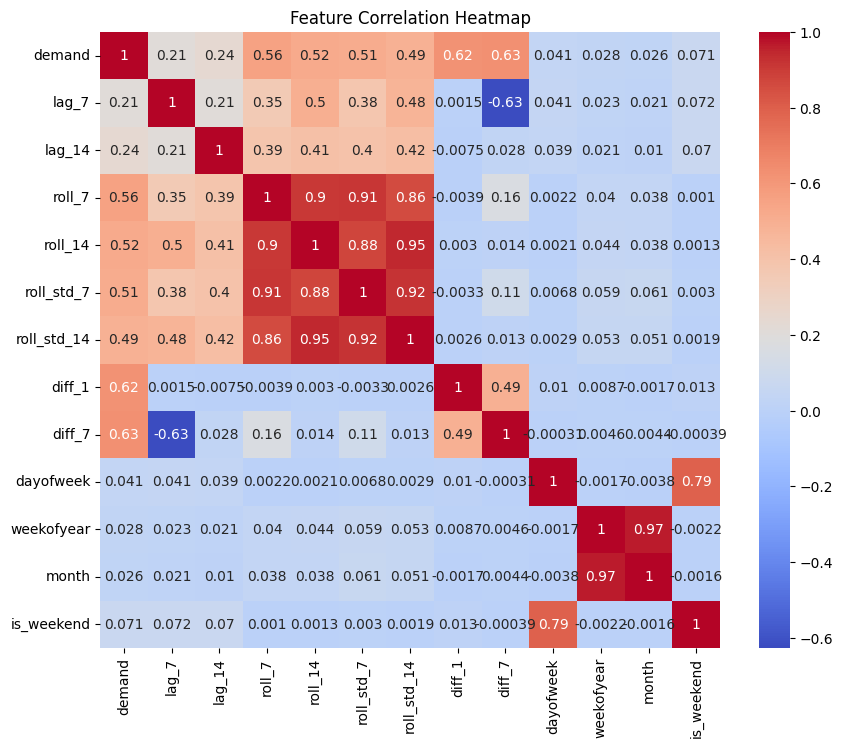

In [22]:
# Select numerical features used in the model
corr_features = [
    "demand",
    "lag_7", "lag_14",
    "roll_7", "roll_14",
    "roll_std_7", "roll_std_14",
    "diff_1", "diff_7",
    "dayofweek", "weekofyear",
    "month", "is_weekend"
]


# correlation matrix
corr_matrix = df[corr_features].corr()

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
)

plt.title("Feature Correlation Heatmap")
plt.show()


**Train&test Data**

In [23]:
train_size = int(len(df) * 0.8)

train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

**Baseline Model**

In [24]:
test["baseline_pred"] = test["roll_7"]


**Random Forest**

In [25]:
rf_features = [
    "lag_7", "lag_14",
    "roll_7", "roll_14",
    "roll_std_7", "roll_std_14",
    "diff_1", "diff_7",
    "dayofweek", "weekofyear",
    "month", "is_weekend"
]


rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_leaf=5,
    random_state=42
)

rf.fit(train[rf_features], train["demand"])
test["rf_pred"] = rf.predict(test[rf_features])



In [26]:
def smape(y_true, y_pred):
    return np.mean(
        2 * np.abs(y_pred - y_true) /
        (np.abs(y_true) + np.abs(y_pred) + 1e-8)
    ) * 100

def evaluate(y_true, y_pred):
    return (
        mean_absolute_error(y_true, y_pred),
        np.sqrt(mean_squared_error(y_true, y_pred)),
        smape(y_true, y_pred)
    )


In [27]:
baseline_metrics = evaluate(test["demand"], test["baseline_pred"])
rf_metrics = evaluate(test["demand"], test["rf_pred"])



**LSTM**

In [28]:
demand = df["demand"].values.reshape(-1, 1)

scaler = MinMaxScaler()
demand_scaled = scaler.fit_transform(demand)

def create_sequences(data, window=14):
    X, y = [], []
    for i in range(window, len(data)):
        X.append(data[i-window:i])
        y.append(data[i])
    return np.array(X), np.array(y)

X_lstm, y_lstm = create_sequences(demand_scaled, 14)

split = int(len(X_lstm) * 0.8)
X_train_lstm, X_test_lstm = X_lstm[:split], X_lstm[split:]
y_train_lstm, y_test_lstm = y_lstm[:split], y_lstm[split:]



In [29]:
model = Sequential([
    LSTM(50, input_shape=(X_train_lstm.shape[1], 1)),
    Dense(1)
])

model.compile(optimizer="adam", loss="mse")

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

model.fit(
    X_train_lstm,
    y_train_lstm,
    validation_split=0.1,
    epochs=50,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0082 - val_loss: 0.0426
Epoch 2/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0079 - val_loss: 0.0430
Epoch 3/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0080 - val_loss: 0.0423
Epoch 4/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0079 - val_loss: 0.0427
Epoch 5/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - loss: 0.0078 - val_loss: 0.0408
Epoch 6/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0078 - val_loss: 0.0418
Epoch 7/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0078 - val_loss: 0.0421
Epoch 8/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0077 - val_loss: 0.0419
Epoch 9/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0076 - val_loss: 0.0444
Epoch 10/50
43/43 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0076 - val_loss: 0.0409


In [30]:
y_pred_lstm = model.predict(X_test_lstm)

y_test_lstm = scaler.inverse_transform(y_test_lstm)
y_pred_lstm = scaler.inverse_transform(y_pred_lstm)

lstm_metrics = evaluate(
    y_test_lstm.flatten(),
    y_pred_lstm.flatten()
)



12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step


**Final Results**

In [31]:
results = pd.DataFrame({
    "Model": ["Moving Average", "Random Forest ", "LSTM"],
    "MAE": [baseline_metrics[0], rf_metrics[0], lstm_metrics[0]],
    "RMSE": [baseline_metrics[1], rf_metrics[1], lstm_metrics[1]],
    "sMAPE (%)": [baseline_metrics[2], rf_metrics[2], lstm_metrics[2]]
})

results = results.sort_values(by="MAE", ascending=True).reset_index(drop=True)

results



,Model,MAE,RMSE,sMAPE (%)
0,Random Forest,0.124421,0.250357,82.096390
1,Moving Average,0.641729,0.851201,119.074427
2,LSTM,0.710535,0.932798,139.743294


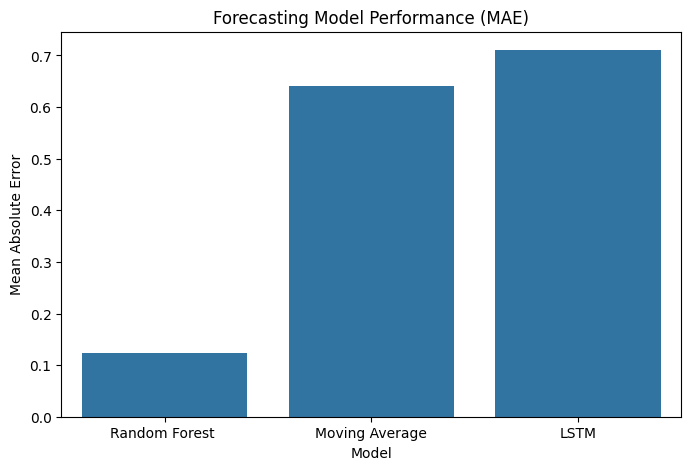

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="MAE",
    data=results
)

plt.title("Forecasting Model Performance (MAE)")
plt.ylabel("Mean Absolute Error")
plt.xlabel("Model")
plt.show()

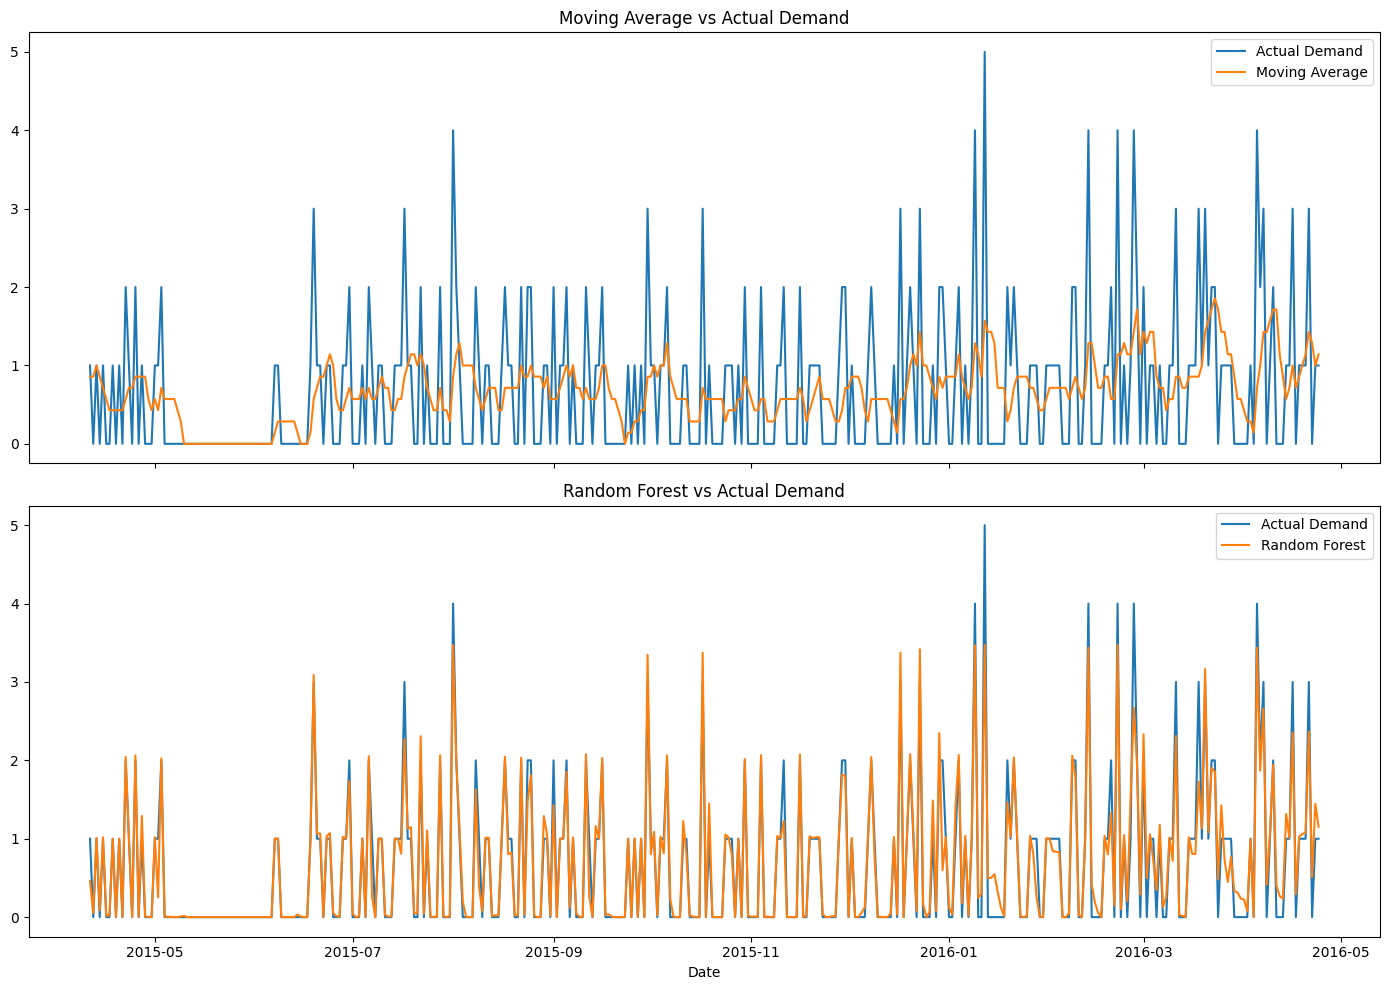

In [33]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(14,10), sharex=True)

# Moving Average
axes[0].plot(test["date"], test["demand"], label="Actual Demand")
axes[0].plot(test["date"], test["baseline_pred"], label="Moving Average")
axes[0].set_title("Moving Average vs Actual Demand")
axes[0].legend()

# Random Forest
axes[1].plot(test["date"], test["demand"], label="Actual Demand")
axes[1].plot(test["date"], test["rf_pred"], label="Random Forest")
axes[1].set_title("Random Forest vs Actual Demand")
axes[1].legend()



plt.xlabel("Date")
plt.tight_layout()
plt.show()